In [1]:
import torch
import torchvision
from torchvision.transforms import transforms
import numpy as np
from matplotlib import pyplot as plt
from torchvision.transforms.v2 import GaussianNoise
from torch import nn
import torch.nn.functional as F
from torch.utils.data import random_split

In [2]:
BATCH_SIZE = 20
STEPS = 5

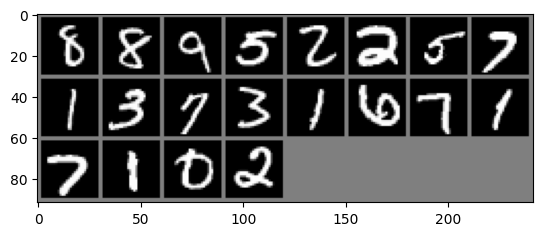

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0.5, 0.5)])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

valset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
valset, testset = random_split(valset, [0.5,0.5])
valloader = torch.utils.data.DataLoader(valset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=1,
                                          shuffle=True, num_workers=2)

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show images
dataiter = iter(trainloader)
images,_ = next(dataiter)
imshow(torchvision.utils.make_grid(images))

In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # for taking the step into account
        self.l1 = nn.Linear(1, 7*7)
        self.l2 = nn.Linear(1, 14*14)
        self.l3 = nn.Linear(1, 28*28)

        # input of 1*28*28
        self.conv1 = nn.Conv2d(2, 16, 3, padding="same") # 2 to 16
        self.conv2 = nn.Conv2d(17, 32, 3, padding="same") # 17 to 32
        #self.conv3 = nn.Conv2d(32, 64, 3, padding="same") # 32 to 64
        self.lin = nn.Linear(33*7*7,32*7*7)

        self.pool = nn.MaxPool2d(2, 2, return_indices=True) # divide image size by 2
        self.unpool = nn.Upsample(scale_factor=2) #multiply image size by 2

        #self.conv4 = nn.Conv2d(64, 32, 3, padding="same") # 64 to 32
        self.conv5 = nn.Conv2d(65, 16, 3, padding="same") # 65 to 16
        self.conv6 = nn.Conv2d(33, 1, 3, padding="same") # 33 to 1

        self.norm = transforms.Normalize(0.5, 0.5)


    def forward(self, x, step): # x: 1*28*28 ; step: 1
        # creating an embedding with the step
        step = step.view(1,1).expand(x.size(0),-1)
        emb1 = F.leaky_relu(self.l3(step)) #28*28
        emb1 = emb1.view(-1,1,28,28) #1*28*28
        emb2 = F.leaky_relu(self.l2(step)) #14*14
        emb2 = emb2.view(-1,1,14,14) #1*14*14
        emb3 = F.leaky_relu(self.l1(step)) #7*7
        emb3 = emb3.view(-1,1,7,7) #1*7*7

        # U-NET
        # 1st part of the encoding of the input
        x1 = torch.cat((x,emb1), dim=1) #2*28*28
        x1 = F.leaky_relu(self.conv1(x1)) #16*28*28

        # 2nd part of the encoding of the input
        x2, indices1 = self.pool(x1) #16*14*14
        x2 = torch.cat((x2,emb2), dim=1) #17*14*14
        x2 = F.leaky_relu(self.conv2(x2)) #32*14*14

        # bottom part of the U-net
        x3, indices2 = self.pool(x2) #32*7*7
        x3 = torch.cat((x3,emb3), dim=1) #33*7*7
        #x3 = F.leaky_relu(self.conv3(x3)) #64*7*7
        #x3 = F.leaky_relu(self.conv4(x3)) #32*7*7
        x3 = x3.view(-1,33*7*7)
        x3 = F.leaky_relu(self.lin(x3)) #32*7*7
        x3 = x3.view(-1,32,7,7)
        x3 = self.unpool(x3) #32*14*14

        # 1st part of the construction of the output
        x = torch.cat((x2, x3, emb2), dim=1) #65*14*14
        x = F.leaky_relu(self.conv5(x)) #16*14*14
        x = self.unpool(x) #16*28*28

        # 2nd part of the construction of the output
        x = torch.cat((x1, x, emb1), dim=1) #33*28*28
        x = (F.sigmoid(self.conv6(x))*2)-1  #1*28*28
        
        return x

In [5]:
def train_model(model, criterion, optimizer, train_loader, val_loader, test_loader, num_epochs, writer, device):
    gaussian = transforms.Compose(
    [GaussianNoise(0.5,0.7),
     transforms.Normalize(0.5, 0.5)])

    min_loss = float('inf')
    early_stopping = 0
    testiter = iter(test_loader)

    # Training and validation
    for epoch in range(num_epochs):
        epoch_training_loss = 0
        epoch_validation_loss = 0

        # Evaluation of the model
        model.eval()
        for _,(images,_) in enumerate(val_loader):
            # Convert images to tensor
            images = torch.Tensor(images).type('torch.FloatTensor')

            # apply STEPS steps of noising and validating the network
            for step in range(STEPS):
                # define input and target
                target_imgs = images.to(device)
                images = gaussian(images).to(device)

                # Forward pass
                outputs = model.forward(images, torch.FloatTensor([STEPS-step]).to(device))

                # Compute loss
                loss = criterion(outputs, target_imgs)

                # Update loss
                epoch_validation_loss += loss.cpu().detach().numpy()
        v_loss = epoch_validation_loss/len(val_loader.dataset)
        writer.add_scalar('Loss/evaluation', v_loss, epoch)

        if v_loss<min_loss:
            torch.save(model, 'best_model.pt')
            min_loss = v_loss
            early_stopping = 0
        else:
            early_stopping += 1

        if early_stopping >= 5:
            break

        # Train model
        model.train()
        for _,(images,_) in enumerate(train_loader):
            # Convert images to tensor
            images = torch.Tensor(images).type('torch.FloatTensor')

            # apply STEPS steps of noising and training the network
            for i in range(STEPS):
                # define input and target
                target_imgs = images.to(device)
                images = gaussian(images).to(device)

                # Forward pass
                outputs = model.forward(images, torch.FloatTensor([STEPS-step]).to(device))

                # Compute loss
                loss = criterion(outputs, target_imgs)

                # Reset gradients
                optimizer.zero_grad()

                # Compute gradients
                loss.backward()

                # Update weights
                optimizer.step()

                # Update loss
                epoch_training_loss += loss.cpu().detach().numpy()
        t_loss = epoch_training_loss/len(train_loader.dataset)
        writer.add_scalar('Loss/training', t_loss, epoch)

        if epoch % 1 == 0:
            print(f'Epoch {epoch}, training loss: {t_loss}, validation loss: {v_loss}')

            img,_ = next(testiter)
            img = img.to(device)
            test = img

            for step in range(STEPS):
                img = gaussian(img)
                test = torch.cat((img,test), dim=0)
            imshow(torchvision.utils.make_grid(test.cpu()))

            pred = img
            for step in range(STEPS):
                img = net.forward(img, torch.FloatTensor([step+1]).to(device))
                pred = torch.cat((pred,img), dim=0)
            imshow(torchvision.utils.make_grid(pred.cpu()))

    return model

In [6]:
from torch.utils.tensorboard import SummaryWriter
from torch import optim

# defining the model
net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.MSELoss()
epochs = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)

2025-04-28 19:21:41.638065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745860901.658086  253053 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745860901.663819  253053 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745860901.678607  253053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745860901.678624  253053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745860901.678626  253053 computation_placer.cc:177] computation placer alr

Epoch 0, training loss: 0.043709564954042435, validation loss: 0.17548300325870514


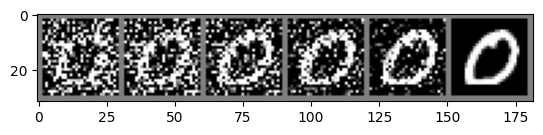

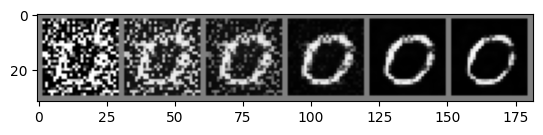

Epoch 1, training loss: 0.04195915535092354, validation loss: 0.045072175562381744


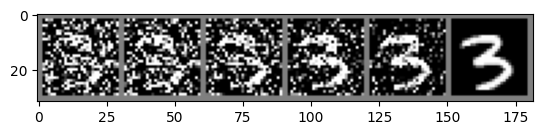

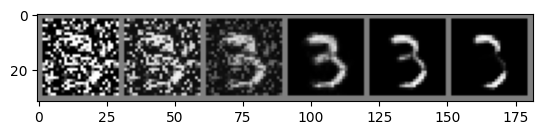

Epoch 2, training loss: 0.04146282374858856, validation loss: 0.04326843097805977


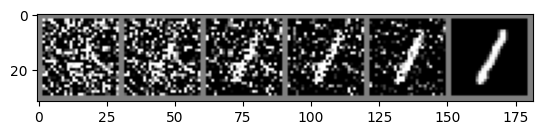

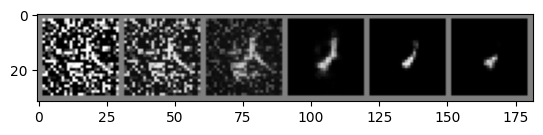

Epoch 3, training loss: 0.04128402844071388, validation loss: 0.0433063805103302


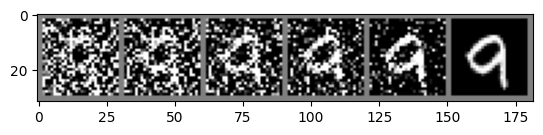

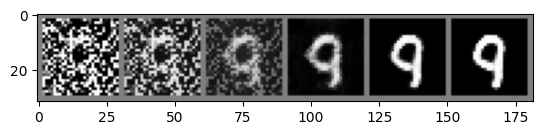

Epoch 4, training loss: 0.041199345141649246, validation loss: 0.04382375627756119


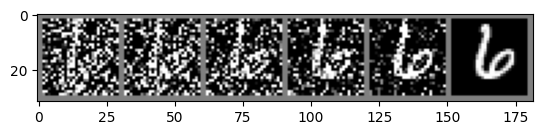

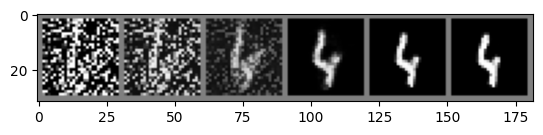

Epoch 5, training loss: 0.041165150701999664, validation loss: 0.04416370391845703


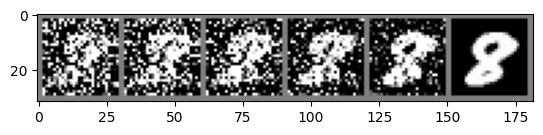

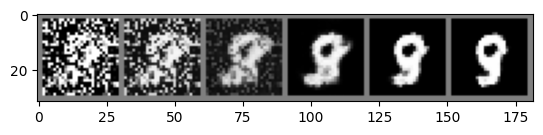

Epoch 6, training loss: 0.04110453277826309, validation loss: 0.04463279992341995


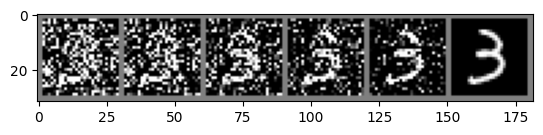

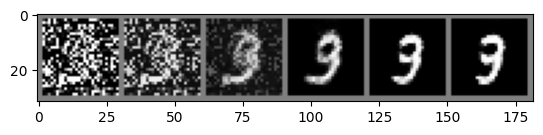

In [7]:
writer = SummaryWriter(comment='diffusionModel')
net = train_model(net, criterion, optimizer, trainloader, valloader, testloader, epochs, writer, device)
writer.close()

In [11]:
model = torch.load('best_model.pt', weights_only=False)

res = []
testiter = iter(testloader)
for i in range(10):
    img,_ = next(testiter)
    img = img.to(device)
    
    for step in range(STEPS):
        img = gaussian(img)
    for step in range(STEPS):
        img = model.forward(img, torch.FloatTensor([step+1]).to(device))
    res.append(img)

img = res[0]
for i in range(len(res)-1):
    torch.cat((img,res[i+1]), dim=0)
imshow(torchvision.utils.make_grid(img))

NameError: name 'gaussian' is not defined